# Two-layer cylinder-shell growth smoke test — outer-surface bulge analysis

Source deck: `t_growth_cylinder_shell.dat` (ANSYS 2022 R2, `usermat_biofilm.f`).

**Model.** A curved substrate (tooth-surface proxy, `R_IN=4.0 -> R_MID=4.3`, `alpha=0`,
no growth) bonded to a thin growth layer (biofilm, `R_MID=4.3 -> R_OUT=4.4`) on top of
it, over an axial length `LEN=3.0` and a 60 deg open arc (a tooth surface patch, not a
closed ring). Finite growth kinematics `F = Fe . Fg`, `Fg = (1+alpha) I`. Inner radius
fully fixed (`D,ALL,ALL,0`); flat axial ends constrained `UZ=0`; everything else
traction-free.

**Status (2026-08-20).** Not a closed-form check — the unit-cube cases
(`t_growth_constrained.dat`, `t_growth_free.dat`) cover that. This is a qualitative
smoke test: does the two-material curved bonded-interface case build/mesh/solve
cleanly, and does it produce a physically sensible deformation pattern? A same-day
alpha sweep found the convergence threshold sits between **alpha=0.01 (converges
clean)** and **alpha=0.015 (6 "element highly distorted" errors)** — well short of
the cube cases' alpha=0.05. Four targeted BC/mesh-refinement attempts to push past
that threshold were tried and reverted (see the deck's own header for the full,
chronological negative-result log); none succeeded. `TBDATA,10,0.01` is the value
actually used for the result loaded below.

**Not confirmed:** whether the pattern found below is a genuine early buckling mode
— that would need a real eigenvalue/buckling analysis, which has not been run.

In [1]:
import csv
import math
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt

# dataviz palette used throughout this repo's ANSYS plots
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
SURFACE = "#fcfcfb"
BLUE = "#2a78d6"
GOOD = "#0ca30c"
GRID = "#e1e0d9"

LEN = 3.0     # axial length
R_OUT = 4.4   # outer growth-layer radius
ALPHA_USED = 0.01

## Load the extracted outer-surface slice

`growth_cylinder_bulge.csv` (`../../assets/`) holds `(theta_deg, u_radial)` pairs at
the outer growth-surface (`R_OUT=4.4`), mid-length (`Z=LEN/2`), extracted from the raw
`PRNSOL,U` + `NLIST` ANSYS output by `extract_cylinder_bulge.py`. The raw result file
(~24 MB) is not committed; regenerate it with
`run_apdl.ps1 -Deck t_growth_cylinder_shell.dat` if you need to re-derive this CSV.

In [2]:
csv_path = Path("../../assets/growth_cylinder_bulge.csv")
rows = []
with open(csv_path, newline="") as f:
    reader = csv.DictReader(f)
    for r in reader:
        rows.append((float(r["theta_deg"]), float(r["u_radial"])))
rows.sort()

theta = [r[0] for r in rows]
u_r = [r[1] for r in rows]
print(f"{len(rows)} points, theta in [{min(theta):.1f}, {max(theta):.1f}] deg")
print(f"u_r in [{min(u_r):.5f}, {max(u_r):.5f}]")

93 points, theta in [0.0, 60.0] deg
u_r in [0.00099, 0.05641]


## Plot: radial displacement vs. arc angle

If the growth layer bulged uniformly outward (the naive expectation for `Fg=(1+alpha)I`
applied to a curved shell bonded down at its inner radius), this curve would be flat.
It is not — it shows a **two-lobe pattern** across the 60 deg arc.

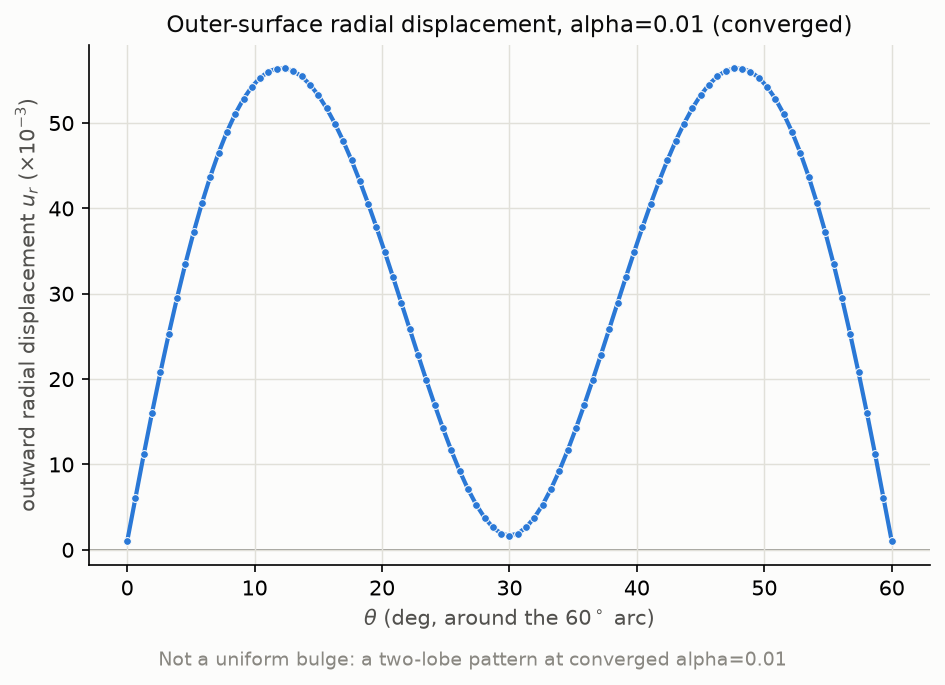

In [3]:
u_r_scaled = [u * 1000 for u in u_r]

fig, ax = plt.subplots(figsize=(6.4, 4.4), dpi=150)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)
ax.plot(theta, u_r_scaled, color=BLUE, linewidth=2.0, zorder=3)
ax.scatter(theta, u_r_scaled, s=14, color=BLUE, zorder=4, edgecolor=SURFACE, linewidth=0.5)
ax.axhline(0, color=INK_MUTED, linewidth=0.8, zorder=1)
ax.set_xlabel(r"$\theta$ (deg, around the 60$^\circ$ arc)", fontsize=10, color=INK_SECONDARY)
ax.set_ylabel(r"outward radial displacement $u_r$ ($\times10^{-3}$)", fontsize=10, color=INK_SECONDARY)
ax.set_title(f"Outer-surface radial displacement, alpha={ALPHA_USED} (converged)", fontsize=11, color=INK_PRIMARY)
ax.grid(True, color=GRID, linewidth=0.7, zorder=0)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.text(0.5, -0.02, "Not a uniform bulge: a two-lobe pattern at converged alpha=0.01",
          ha="center", fontsize=9, color=INK_MUTED)
fig.tight_layout()
plt.show()

## 3D geometry + boundary conditions + displaced outer surface

Reconstructs the deck's geometry (`CSYS,1`: `R_IN=4.0 -> R_MID=4.3` substrate,
`R_MID -> R_OUT=4.4` growth layer, `LEN=3.0`, 60 deg open arc) and overlays the two
boundary conditions actually applied:

- **inner radius `R_IN`** (gray, translucent): `D,ALL,ALL,0` — fully fixed, stands in
  for "attached to the rest of the tooth".
- **flat axial-end faces at `Z=0` and `Z=LEN`** (hatched): `D,ALL,UZ,0` — the
  constraint that dropped the error count from 12 to 3 (see the deck header).

The outer growth-surface is colored by the extracted radial displacement `u_r(theta)`
and drawn **exaggerated** (see `EXAGGERATION` below) so the two-lobe pattern is visible
by eye. Only the mid-length (`Z=LEN/2`) slice was actually extracted from ANSYS output
(`extract_cylinder_bulge.py` only pulls that one slice) — the same profile is repeated
along `Z` here purely for a readable 3D shape, **not** a per-Z-station measurement. The
theta-edges (`Y=0`, `Y=ARC`) are traction-free, not shown as a constraint.

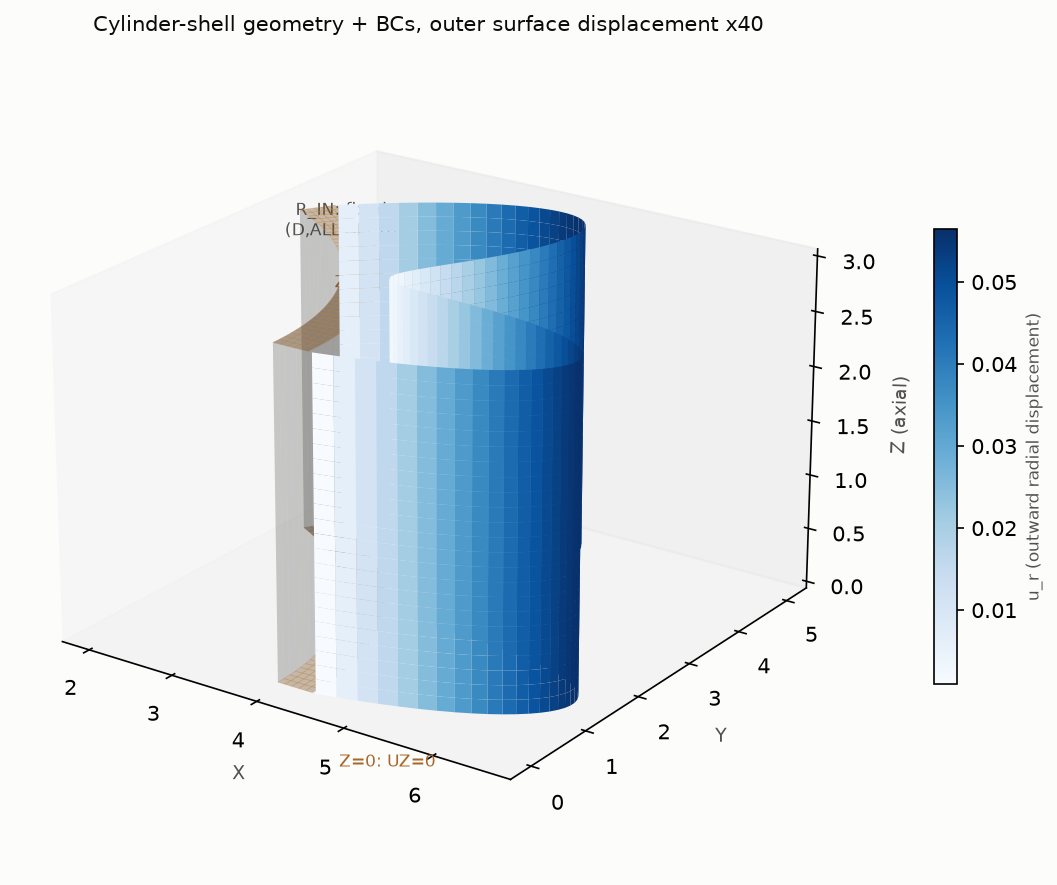

In [4]:
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers the 3D projection)

R_IN = 4.0
R_MID = 4.3
ARC_DEG = 60.0
EXAGGERATION = 40.0  # displacement is ~0.06 units on a ~4.4-unit radius -- invisible unscaled

theta_arr = np.array(theta)
u_r_arr = np.array(u_r)
theta_rad = np.radians(theta_arr)

n_z = 24
z_grid = np.linspace(0, LEN, n_z)
Theta, Z = np.meshgrid(theta_rad, z_grid)
U = np.tile(u_r_arr, (n_z, 1))
R = R_OUT + EXAGGERATION * U

X = R * np.cos(Theta)
Y = R * np.sin(Theta)

norm = plt.Normalize(vmin=u_r_arr.min(), vmax=u_r_arr.max())
cmap = plt.get_cmap("Blues")
facecolors = cmap(norm(U))

fig = plt.figure(figsize=(8.0, 6.0), dpi=150)
fig.patch.set_facecolor(SURFACE)
ax = fig.add_subplot(111, projection="3d")
ax.set_facecolor(SURFACE)

# displaced, colored growth-layer outer surface
ax.plot_surface(X, Y, Z, facecolors=facecolors, rstride=1, cstride=1,
                 linewidth=0, antialiased=True, shade=False, zorder=2)

# inner radius: fixed (D,ALL,ALL,0) -- gray, translucent
theta_fine = np.linspace(0, np.radians(ARC_DEG), 40)
Theta_in, Z_in = np.meshgrid(theta_fine, [0, LEN])
X_in = R_IN * np.cos(Theta_in)
Y_in = R_IN * np.sin(Theta_in)
ax.plot_surface(X_in, Y_in, Z_in, color=INK_MUTED, alpha=0.25, linewidth=0, zorder=1)
ax.text(R_IN * math.cos(math.radians(ARC_DEG / 2)), R_IN * math.sin(math.radians(ARC_DEG / 2)),
        LEN * 1.12, "R_IN: fixed\n(D,ALL,ALL,0)", color=INK_SECONDARY, fontsize=8, ha="center")

# axial-end faces: UZ=0 -- hatched rings at Z=0 and Z=LEN
for z_end, label_dy in [(0.0, -0.35), (LEN, 0.35)]:
    r_ring = np.linspace(R_IN, R_OUT, 6)
    Theta_end, R_end = np.meshgrid(theta_fine, r_ring)
    X_end = R_end * np.cos(Theta_end)
    Y_end = R_end * np.sin(Theta_end)
    Z_end = np.full_like(X_end, z_end)
    ax.plot_surface(X_end, Y_end, Z_end, color="#c9853a", alpha=0.35,
                     linewidth=0.3, edgecolor="#c9853a", zorder=1)
ax.text(R_OUT * math.cos(0) + 0.3, R_OUT * math.sin(0), -0.6,
        "Z=0: UZ=0", color="#a8672a", fontsize=8, ha="left")
ax.text(R_OUT * math.cos(0) + 0.3, R_OUT * math.sin(0), LEN + 0.6,
        "Z=LEN: UZ=0", color="#a8672a", fontsize=8, ha="left")

ax.set_xlabel("X", fontsize=9, color=INK_SECONDARY)
ax.set_ylabel("Y", fontsize=9, color=INK_SECONDARY)
ax.set_zlabel("Z (axial)", fontsize=9, color=INK_SECONDARY)
ax.set_title(f"Cylinder-shell geometry + BCs, outer surface displacement x{EXAGGERATION:.0f}",
             fontsize=10, color=INK_PRIMARY)
ax.set_box_aspect((1, 1, LEN / R_OUT))
ax.view_init(elev=22, azim=-55)
ax.grid(False)

mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
mappable.set_array([])
cbar = fig.colorbar(mappable, ax=ax, shrink=0.55, pad=0.08)
cbar.set_label("u_r (outward radial displacement)", fontsize=8, color=INK_SECONDARY)

fig.tight_layout()
plt.show()

## Quick lobe check

Count sign changes / local extrema in `u_r(theta)` as a rough, non-rigorous signature
of the two-lobe pattern (NOT a substitute for an eigenvalue/buckling analysis).

In [5]:
def count_local_extrema(ys):
    n = 0
    for i in range(1, len(ys) - 1):
        if (ys[i] - ys[i - 1]) * (ys[i + 1] - ys[i]) < 0:
            n += 1
    return n

n_extrema = count_local_extrema(u_r_scaled)
print(f"local extrema in u_r(theta): {n_extrema}")
print("(a clean single-lobe/uniform bulge would show ~0-1; two lobes shows ~2)")

local extrema in u_r(theta): 3
(a clean single-lobe/uniform bulge would show ~0-1; two lobes shows ~2)


## Alpha sweep summary (from the deck's convergence log)

Not re-run here (each point is a real ANSYS solve, minutes each) — this is a static
record of the sweep already performed and documented in `t_growth_cylinder_shell.dat`'s
header, kept alongside the displacement plot for reference in the same notebook.

alpha=0.005  OK    converges clean
alpha=0.01   OK    converges clean -- used for the result above
alpha=0.015  FAIL  6 'element highly distorted' errors
alpha=0.05   FAIL  target value (cube cases' alpha) -- fails


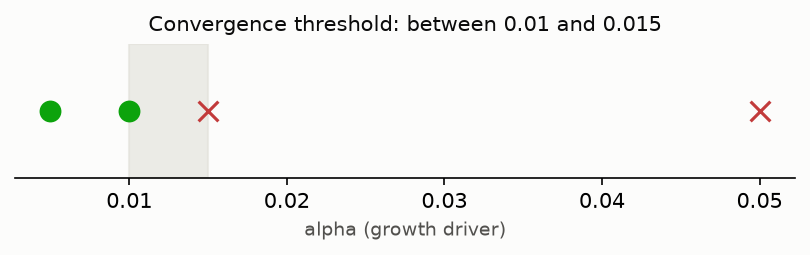

In [6]:
alpha_sweep = [
    # (alpha, converged, note)
    (0.005, True,  "converges clean"),
    (0.01,  True,  "converges clean -- used for the result above"),
    (0.015, False, "6 'element highly distorted' errors"),
    (0.05,  False, "target value (cube cases' alpha) -- fails"),
]
for a, ok, note in alpha_sweep:
    mark = "OK  " if ok else "FAIL"
    print(f"alpha={a:<6} {mark}  {note}")

fig, ax = plt.subplots(figsize=(5.5, 1.8), dpi=150)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)
for a, ok, _ in alpha_sweep:
    ax.scatter([a], [0], s=90, color=(GOOD if ok else "#c23b3b"), zorder=3,
               marker="o" if ok else "x")
ax.axvspan(0.01, 0.015, color=GRID, alpha=0.6, zorder=1)
ax.set_yticks([])
ax.set_xlabel("alpha (growth driver)", fontsize=9, color=INK_SECONDARY)
ax.set_title("Convergence threshold: between 0.01 and 0.015", fontsize=10, color=INK_PRIMARY)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()